# Car Detection in Snow – Main Notebook
**Course:** D7047E Advanced Deep Learning | LTU VT2026  
**Dataset:** [Nordic Vehicle Dataset (NVD)](https://nvd.ltu-ai.dev/)  
**Base model:** YOLOv9 via `ultralytics`

---

This is the single entry-point notebook for the project. It is organised into the following sections:

1. [Environment & Imports](#1-environment--imports)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis-eda)
3. [Dataset Preparation](#3-dataset-preparation)
4. [Training](#4-training)
   - 4.1 Zero-shot baseline — YOLOv9 (COCO-pretrained, no fine-tuning)
   - 4.2 YOLOv9 fine-tuning
   - 4.3 COCO-format conversion for RT-DETR
   - 4.4 RT-DETR zero-shot baseline
   - 4.5 RT-DETR fine-tuning
   - 4.6 Faster R-CNN fine-tuning
   - 4.7 Faster R-CNN zero-shot baseline
   - 4.8 Results comparison table
5. [Phase 3 — Augmentation Ablation & Hyperparameter Sweep](#phase-3)
   - 4.9 Augmentation preview
   - 4.9A YOLOv9 snow augmentation training
   - 4.9B YOLOv9 full augmentation training
   - 4.10A RT-DETR snow augmentation training
   - 4.10B RT-DETR full augmentation training
   - 4.11A Faster R-CNN snow augmentation training
   - 4.11B Faster R-CNN full augmentation training
   - 4.12 Augmentation ablation results
   - 4.13 Hyperparameter sweep
   - 4.14 Final model training
6. [Evaluation](#5-evaluation)
7. [Error Analysis](#6-error-analysis)


## 1. Environment & Imports

In [1]:

import os
import random
from pathlib import Path
import shutil

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

import yaml

# Reproducibility
random.seed(42)
np.random.seed(42)

# Paths
ROOT       = Path(".").resolve()  # project root
DATA_RAW   = ROOT / "data" / "raw"
DATA_PROC  = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
RESULTS    = ROOT / "results"
FIGURES    = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print(ROOT)
print(MODELS_DIR)
print("Paths OK")

/home/jovyan/Advance_AI/Project
/home/jovyan/Advance_AI/Project/models
Paths OK


## 2. Exploratory Data Analysis (EDA)

In [2]:

# -- EDA - Step 1: Load annotations ------------------------------------------
# NVD uses a FLAT layout: all splits share the same images/ and labels/ dirs.
# Each split loads only the frames listed in its .txt file.

import sys
sys.path.insert(0, str(ROOT / "scripts"))

from data_utils import load_yolo_split_from_txt, compute_stats
from data_utils.reporting import print_stats

# Load split paths from the recording-level config (avoids temporal leakage)
EDA_YAML = ROOT / "configs" / "data_rec_sub.yaml"
with open(EDA_YAML) as f:
    _cfg = yaml.safe_load(f)
_ds_root = (EDA_YAML.parent / _cfg["path"]).resolve()

CLASS_NAMES = ["car"]

train_split = load_yolo_split_from_txt(_ds_root / _cfg["train"], root=_ds_root, split_name="train", class_names=CLASS_NAMES)
val_split   = load_yolo_split_from_txt(_ds_root / _cfg["val"],   root=_ds_root, split_name="val",   class_names=CLASS_NAMES)
test_split  = load_yolo_split_from_txt(_ds_root / _cfg["test"],  root=_ds_root, split_name="test",  class_names=CLASS_NAMES)

splits = [train_split, val_split, test_split]

for split in splits:
    stats = compute_stats(split)
    print_stats(stats)



  Split : train
  Images: 3029
  Boxes : 9497  (avg 3.1 per image)
  Images without annotations: 0

  Class counts:
    car                    9497

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 2665
    Images with missing dims: 0


  Split : val
  Images: 1203
  Boxes : 4168  (avg 3.5 per image)
  Images without annotations: 0

  Class counts:
    car                    4168

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 27
    Images with missing dims: 0


  Split : test
  Images: 1191
  Boxes : 3169  (avg 2.7 per image)
  Images without annotations: 0

  Class counts:
    car                    3169

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 950
    Images with missing dims: 0



In [3]:

# -- EDA - Annotation quality check ---
# Surfaces potential issues to document in the Methodology section:
#   - Images with no annotations (empty frames)
#   - Crowd boxes (iscrowd=1): groups annotated as one box, not per-instance
#   - Tiny boxes (<32x32 px): often truncated objects at frame edges or label noise
#   - Images where width/height was missing in the annotation file

for split in splits:
    stats = compute_stats(split)
    print(f"[{split.name}]  crowd={stats['crowd_boxes']}  "
          f"tiny={stats['tiny_boxes']}  "
          f"empty_images={stats['images_without_boxes']}  "
          f"missing_dims={stats['missing_dims']}")


[train]  crowd=0  tiny=2665  empty_images=0  missing_dims=0
[val]  crowd=0  tiny=27  empty_images=0  missing_dims=0
[test]  crowd=0  tiny=950  empty_images=0  missing_dims=0


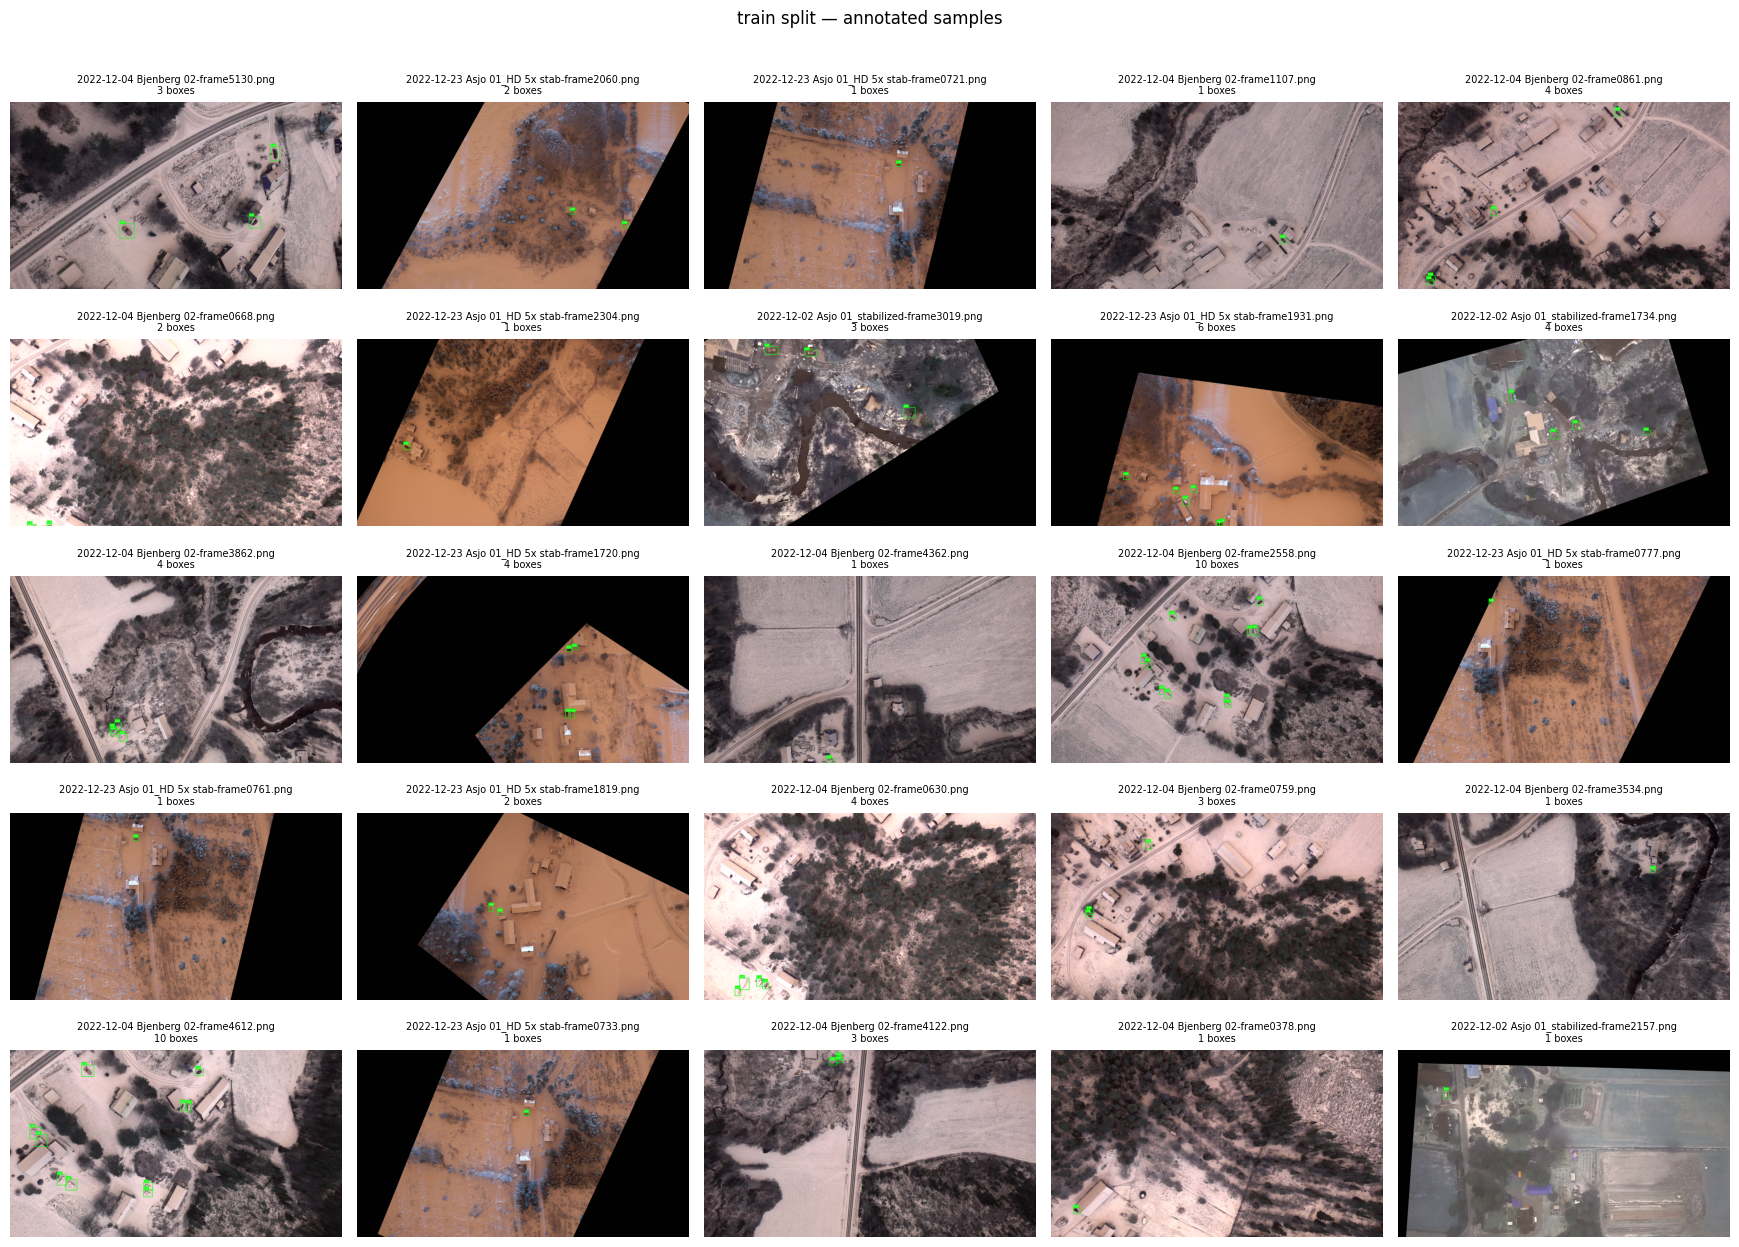

In [4]:

# -- EDA - Step 2: Visualise annotated samples --------------------------------
from eda.visualizer import plot_annotated_samples

fig = plot_annotated_samples(train_split, n=25, cols=5, seed=42)
fig.savefig(FIGURES / "eda_annotated_samples.png", bbox_inches="tight", dpi=120)
plt.show()


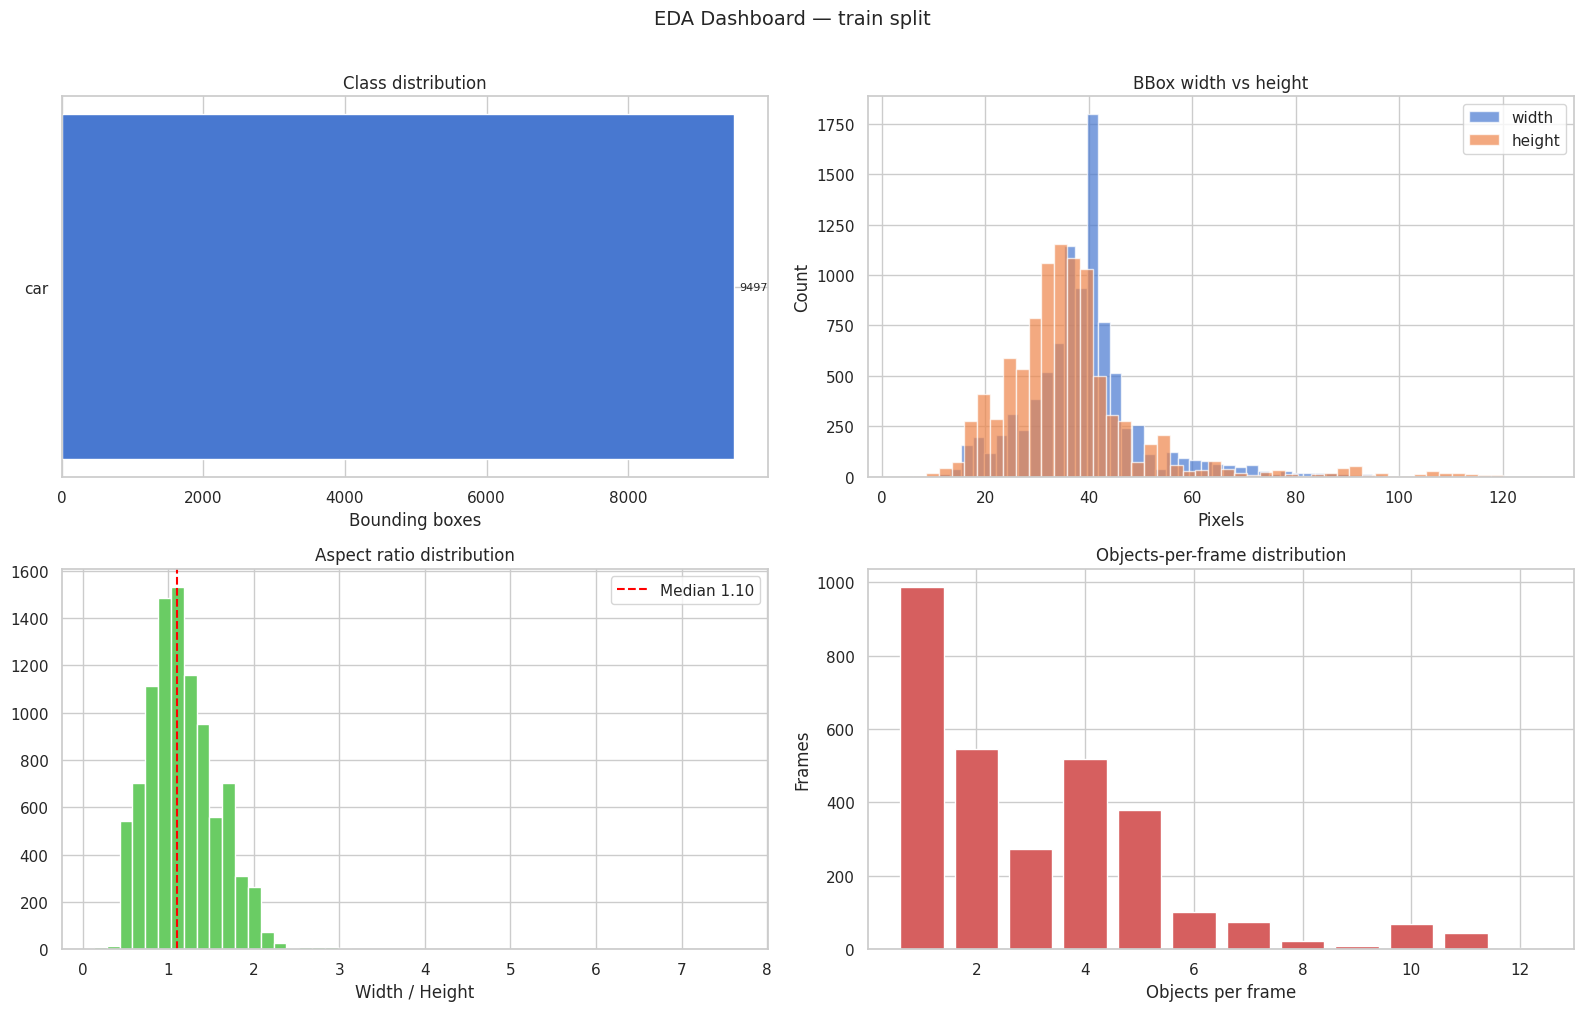

In [5]:

# -- EDA - Step 3: Distribution plots (all four in one dashboard) -------------
from eda.plots import plot_eda_dashboard

train_stats = compute_stats(train_split)

fig = plot_eda_dashboard(train_stats)
fig.savefig(FIGURES / "eda_dashboard_train.png", bbox_inches="tight", dpi=120)
plt.show()


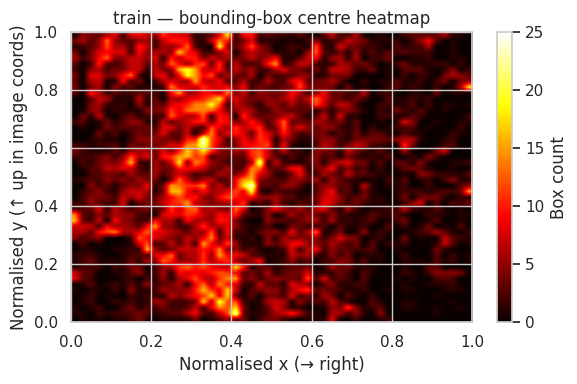

In [6]:

# -- EDA - Step 4: Bounding-box centre heatmap --------------------------------
from eda.visualizer import plot_bbox_heatmap

fig = plot_bbox_heatmap(train_stats)
fig.savefig(FIGURES / "eda_bbox_heatmap_train.png", bbox_inches="tight", dpi=120)
plt.show()


## 3. Dataset Preparation

No conversion needed – the NVD dataset is already in YOLO format.
`configs/data.yaml` points directly to the raw data and can be passed straight to ultralytics.

Run the cells below once to verify the dataset is correctly set up before training.

In [7]:

# -- Dataset Preparation - Step 2: Verify annotations visually ----------------
# Draws bounding boxes on a sample of images and saves them to results/figures/.
# Equivalent terminal command:
#   python scripts/verify_annotations.py --data-yaml configs/data_rec_sub.yaml --split train --n 10 --output results/figures/verify_train/

import subprocess
import sys

result = subprocess.run(
    [sys.executable, "scripts/verify_annotations.py",
     "--data-yaml", "configs/data_rec_sub.yaml",
     "--split", "train",
     "--n", "10",
     "--output", "results/figures/verify_train/"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Saved 10 verified images to: results/figures/verify_train



## 4. Training

All training runs use the `scripts/training/` package (SRP/SoC design):  
- `training.models` — `TrainingConfig`, `EvalMetrics` dataclasses  
- `training.yolo_trainer` — YOLOv9 zero-shot eval + fine-tuning  
- `training.detr_trainer` — RT-DETR fine-tuning + eval  
- `training.frcnn_trainer` — Faster R-CNN fine-tuning + eval  
- `training.evaluator` — vendor result → `EvalMetrics` conversion  
- `training.results_writer` — CSV persistence  

Results accumulate in `results/model_comparison.csv`.

In [8]:
# --- Phase 2 imports & shared config ----------------------------------------
import sys
from pathlib import Path

sys.path.insert(0, str(ROOT / "scripts"))

from training import (
    TrainingConfig,
    EvalMetrics,
    run_yolo_zero_shot_eval,
    run_yolo_fine_tuning,
    eval_yolo_checkpoint,
    eval_yolo_sahi,
    eval_frcnn_sahi,
    run_detr_zero_shot_eval,
    run_detr_fine_tuning,
    eval_detr_checkpoint,
    run_frcnn_zero_shot_eval,
    run_frcnn_fine_tuning,
    eval_frcnn_checkpoint,
    save_zero_shot_result,
    append_comparison_row,
)

# ─── DATA SPLIT SELECTION ─────────────────────────────────────────────────────
# IMPORTANT: Use the recording-level split to avoid temporal leakage.
# The frame-level split (data.yaml) gives inflated val mAP (~0.99) because
# train and val share frames from the same video recordings.
#
# Options:
#   data_rec.yaml     — recording-level split (honest val, all train frames)
#   data_rec_sub.yaml — recording-level + subsampled (every Nth frame, less redundancy)

# Recording-level split with subsampled training frames (recommended)
DATA_YAML     = str(ROOT / "configs" / "data_rec_sub.yaml")

# Full recording-level split (alternative — more data but higher redundancy)
# DATA_YAML   = str(ROOT / "configs" / "data_rec.yaml")

COMPARISON_CSV   = str(RESULTS / "model_comparison.csv")
TRAIN_COCO_JSON  = str(DATA_PROC / "annotations" / "instances_train.json")
VAL_COCO_JSON    = str(DATA_PROC / "annotations" / "instances_val.json")
IMAGES_DIR       = str(DATA_RAW / "images")

# Change to "cpu" if no GPU is available
DEVICE = "0"

print("Phase 2 imports OK")
print(f"Data config: {DATA_YAML}")

Phase 2 imports OK
Data config: /home/jovyan/Advance_AI/Project/configs/data_rec_sub.yaml


In [9]:
from scripts.training.yolo_trainer import eval_checkpoint

metrics = eval_checkpoint(
    weights="/home/jovyan/Advance_AI/Project/models/yolov9c/yolov9_nvd/weights/best.pt",
    data_yaml="/home/jovyan/Advance_AI/Project/configs/data_rec_sub.yaml",
    split="test",
    device="0",
    model_label="yolov9_nvd",
)
print(metrics)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: deeplab15group (deeplab15group-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Ultralytics 8.4.51 🚀 Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
YOLOv9c summary (fused): 156 layers, 25,320,019 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2148.7±1600.1 MB/s, size: 2483.9 KB)
val: Scanning /home/jovyan/Advance_AI/Project/data/raw/labels... 1191 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1191/1191 123.5it/s 9.6s0.0s
val: New cache created: /home/jovyan/Advance_AI/Project/data/raw/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 2.2it/s 34.3s0.4ss
                   all       1191       3169      0.163       0.26      0.119     0.0421
Speed: 1.9ms preprocess, 23.9ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /runs/detect/val-27


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,41.9
eval/map50,0.11858
eval/map50_95,0.04207
eval/precision,0.16281
eval/recall,0.2597


EvalMetrics(model='yolov9_nvd', pretrain='COCO → NVD', fine_tuned=True, split='test', map50=0.11858348582310113, map50_95=0.042072638686683955, precision=0.16280909990108802, recall=0.2597033764594509, fps=41.9, notes='')


### 4.1 Zero-shot baseline

Run COCO-pretrained YOLOv9 on the NVD val set **without any fine-tuning**.  
This is the "before" anchor that makes fine-tuning gains meaningful.  
Result saved to `results/baseline_zero_shot.csv`.


In [ ]:

# Run once before training anything — sets the "before fine-tuning" anchor.
baseline_metrics = run_yolo_zero_shot_eval(
    model_name="yolov9c.pt",
    data_yaml=DATA_YAML,
    split="val",
    device=DEVICE,
)


append_comparison_row(baseline_metrics, COMPARISON_CSV)

print(f"mAP@0.5     : {baseline_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {baseline_metrics.map50_95:.4f}")
print(f"Precision   : {baseline_metrics.precision:.4f}")
print(f"Recall      : {baseline_metrics.recall:.4f}")
print(f"FPS         : {baseline_metrics.fps:.1f}")


### 4.2 YOLOv9 fine-tuning

Fine-tune `yolov9c` on the NVD training split.  
- Backbone frozen for the first run (`freeze=10`) — only the detection head adapts.  
- Best checkpoint copied to `models/yolov9_nvd_best.pt`.


In [ ]:

# ── 4.2 YOLOv9 fine-tuning (no custom augmentation — ablation baseline) ──────
# Optimised for small-object aerial detection (~20px cars in 1920×1080 frames):
#   • mosaic=0.0   — prevents shrinking 20px objects to undetectable 10px
#   • aug="crop"   — random 640×640 crops at native res → cars stay at ~38px
#   • nbs=64       — gradient accumulation smooths batch=4 noise
#   • scale=0.2    — minimal random resize to keep objects above detection threshold
#   • No mixup     — blending destroys tiny object signal
#
# The "crop" augmentation randomly crops 640×640 patches from the ORIGINAL
# resolution image (1920×1080), so the model sees cars at their native ~38px
# size rather than the shrunk ~20px from full-image resize to 1024.

yolo_config = TrainingConfig(
    model_name="yolov9c",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    imgsz=1280,
    lr0=0.0003,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    nbs=64,  
    freeze=None,
    device=DEVICE,
    output_dir=str(MODELS_DIR / "yolov9c"),
    run_name="yolov9_nvd",
    mosaic=0.0,
    close_mosaic=0,
    patience=50,
    # -- Generalization knobs (same for ALL 9 runs) --
    mixup=0.0,
    copy_paste=0.1,
    scale=0.2,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
)


yolo_best_pt = run_yolo_fine_tuning(yolo_config, aug_variant="crop")

# Copy to canonical model path
yolo_dest = MODELS_DIR / "yolov9_nvd_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(yolo_best_pt, yolo_dest)
print(f"Best checkpoint → {yolo_dest}")

# Evaluate on val set
yolo_metrics = eval_yolo_checkpoint(
    weights=yolo_dest,
    data_yaml=DATA_YAML,
    split="val",
    device=DEVICE,
    model_label="YOLOv9c (fine-tuned)",
)
append_comparison_row(yolo_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {yolo_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {yolo_metrics.map50_95:.4f}")
print(f"Precision   : {yolo_metrics.precision:.4f}")
print(f"Recall      : {yolo_metrics.recall:.4f}")
print(f"FPS         : {yolo_metrics.fps:.1f}")


### 4.9C YOLOv9 High-Resolution Training (imgsz=1280)

Higher input resolution preserves more small-object detail (cars ~25px at 1280 vs ~20px at 1024).
Trade-off: requires batch=2 to fit on RTX 2080 Ti 11GB.
Uses the best augmentation variant from 4.9A/B for a direct resolution comparison.

In [ ]:
# ── 4.9C YOLOv9 high-resolution training (imgsz=1280, batch=2) ─────────────────
# Higher resolution: cars ~25px at 1280 vs ~20px at 1024.
# Combined with no-mosaic, this gives the model the clearest view of small objects.

hires_config = TrainingConfig(
    model_name="yolov9c",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,           # Reduced from 4 to fit imgsz=1280 in 11GB VRAM
    imgsz=1280,        # Higher resolution for small-object performance
    lr0=0.0003,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    nbs=64,       
    freeze=None,
    device=DEVICE,
    output_dir=str((MODELS_DIR / "yolov9c").resolve()),
    run_name="yolov9_hires",
    mosaic=0,
    close_mosaic=0,
    patience=50,
    mixup=0.0,
    copy_paste=0.1,
    scale=0.2,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
)

hires_best_pt = run_yolo_fine_tuning(hires_config, aug_variant="none")
hires_dest = MODELS_DIR / "yolov9_hires_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(hires_best_pt, hires_dest)
print(f"High-res checkpoint → {hires_dest}")

hires_metrics = eval_yolo_checkpoint(
    weights=hires_dest,
    data_yaml=DATA_YAML,
    split="val",
    device=DEVICE,
    model_label="YOLOv9c (1280, no aug)",
)
append_comparison_row(hires_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {hires_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {hires_metrics.map50_95:.4f}")
print(f"Precision   : {hires_metrics.precision:.4f}")
print(f"Recall      : {hires_metrics.recall:.4f}")
print(f"FPS         : {hires_metrics.fps:.1f}")

### 4.3 COCO-format conversion for RT DETR

Before running DETR training, generate COCO JSON annotations from the YOLO split files.
This step creates `data/processed/annotations/instances_train.json` and `instances_val.json`.
</VSCode.Cell>
<VSCode.Cell language="python">

In [ ]:

import subprocess
import sys

result = subprocess.run(
    [sys.executable, "scripts/prepare_coco_format.py",
     "--data-yaml", DATA_YAML,
     "--output", str(DATA_PROC)],
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
else:
    print("COCO format annotations generated successfully.")

### 4.4 RT DETR Zero-shot baseline

In [ ]:

# Zero-shot RT-DETR — COCO-pretrained, no fine-tuning
# Prerequisite: COCO JSON annotations must exist (run the prepare_coco_format cell first)
rtdetr_zs_metrics = run_detr_zero_shot_eval(
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    model_name="PekingU/rtdetr_r50vd",
    split="val",
    device_str=DEVICE,
)


append_comparison_row(rtdetr_zs_metrics, COMPARISON_CSV)

print(f"mAP@0.5     : {rtdetr_zs_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {rtdetr_zs_metrics.map50_95:.4f}")
print(f"Precision   : {rtdetr_zs_metrics.precision:.4f}")
print(f"Recall      : {rtdetr_zs_metrics.recall:.4f}")
print(f"FPS         : {rtdetr_zs_metrics.fps:.1f}")


### 4.5 RT-DETR fine-tuning

In [ ]:

# ── 4.5 RT-DETR fine-tuning (no custom augmentation — ablation baseline) ─────
# Crop augmentation gives the transformer encoder larger objects (~38px vs ~20px).
# RT-DETR's global attention can still capture context from the cropped region.

rtdetr_config = TrainingConfig(
    model_name="PekingU/rtdetr_r50vd",
    data_yaml="",              # RT-DETR uses COCO JSON, not data.yaml
    epochs=200,
    batch=3,
    imgsz=1280,
    lr0=1e-5,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "rtdetr").resolve()),
    run_name="rtdetr_nvd",
)

rtdetr_best_dir = run_detr_fine_tuning(
    rtdetr_config,
    train_json=TRAIN_COCO_JSON,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    aug_variant="crop",
)
print(f"Best checkpoint → {rtdetr_best_dir}")

rtdetr_metrics = eval_detr_checkpoint(
    checkpoint_dir=rtdetr_best_dir,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    split="val",
    device_str=DEVICE,
    imgsz=640,
    model_label="RT-DETR (fine-tuned)",
)
append_comparison_row(rtdetr_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {rtdetr_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {rtdetr_metrics.map50_95:.4f}")
print(f"Precision   : {rtdetr_metrics.precision:.4f}")
print(f"Recall      : {rtdetr_metrics.recall:.4f}")
print(f"FPS         : {rtdetr_metrics.fps:.1f}")


### 4.6 Faster R-CNN 

Fine-tune `fasterrcnn_resnet50_fpn` (torchvision) on NVD.  
Reads YOLO-format labels directly — no COCO JSON required.  
Gives a classic two-stage detector baseline to compare against.


### Faster R-CNN Zero-shot Baseline


In [ ]:

# Zero-shot Faster R-CNN — COCO-pretrained, no fine-tuning
frcnn_zs_metrics = run_frcnn_zero_shot_eval(
    data_yaml=DATA_YAML,
    split="val",
    device_str=DEVICE,
)

append_comparison_row(frcnn_zs_metrics, COMPARISON_CSV)

print(f"mAP@0.5     : {frcnn_zs_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {frcnn_zs_metrics.map50_95:.4f}")
print(f"Precision   : {frcnn_zs_metrics.precision:.4f}")
print(f"Recall      : {frcnn_zs_metrics.recall:.4f}")
print(f"FPS         : {frcnn_zs_metrics.fps:.1f}")


### 4.7 Faster R-CNN Fine-tuning


In [ ]:

# ── 4.7 Faster R-CNN fine-tuning (no custom augmentation — ablation baseline) ─
# Crop augmentation preserves object size for FPN's multi-scale detection heads.

frcnn_config = TrainingConfig(
    model_name="fasterrcnn_resnet50_fpn",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    imgsz=1280,
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=25,
    output_dir=str(MODELS_DIR / "frcnn"),
    run_name="frcnn_nvd",
)

frcnn_best_pt = run_frcnn_fine_tuning(frcnn_config, data_yaml=DATA_YAML, aug_variant="crop")

frcnn_dest = MODELS_DIR / "frcnn_nvd_best.pt"
shutil.copy2(frcnn_best_pt, frcnn_dest)
print(f"Best checkpoint → {frcnn_dest}")

frcnn_metrics = eval_frcnn_checkpoint(
    weights=frcnn_dest,
    data_yaml=DATA_YAML,
    split="val",
    device_str=DEVICE,
    model_label="Faster R-CNN (fine-tuned)",
)
append_comparison_row(frcnn_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {frcnn_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {frcnn_metrics.map50_95:.4f}")
print(f"Precision   : {frcnn_metrics.precision:.4f}")
print(f"Recall      : {frcnn_metrics.recall:.4f}")
print(f"FPS         : {frcnn_metrics.fps:.1f}")


### 4.8 Results comparison table

Load `results/model_comparison.csv` and display all models side by side.


In [ ]:

import pandas as pd

comparison_path = Path(COMPARISON_CSV)
if comparison_path.exists():
    df = pd.read_csv(comparison_path)
    # Highlight best value per numeric column
    numeric_cols = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "FPS"]
    display(
        df.style
          .highlight_max(subset=numeric_cols, color="lightgreen")
          .format({c: "{:.4f}" for c in numeric_cols if c != "FPS"})
          .format({"FPS": "{:.1f}"})
          .set_caption("Phase 2 — Model Comparison (val set)")
    )
else:
    print(f"No comparison CSV yet at {comparison_path}. Run the training cells first.")


---
<a id="phase-3"></a>

## Phase 3 — Augmentation Ablation 

Nine training runs compare **3 models × 3 augmentation variants**:

| Section | Model | Augmentation | Run name |
|---------|-------|-------------|----------|
| 4.2  | YOLOv9c | None (ultralytics default) | `yolov9_nvd` |
| 4.9A  | YOLOv9c | Snow | `yolov9_snow` |
| 4.9B  | YOLOv9c | Full | `yolov9_full` |
| 4.5  | RT-DETR | None | `rtdetr_nvd` |
| 4.10A | RT-DETR | Snow | `rtdetr_snow` |
| 4.10B | RT-DETR | Full | `rtdetr_full` |
| 4.7  | Faster R-CNN | None | `frcnn_nvd` |
| 4.11A | Faster R-CNN | Snow | `frcnn_snow` |
| 4.11B | Faster R-CNN | Full | `frcnn_full` |

**Snow pipeline:** `RandomSnow` + `RandomFog` + `RandomBrightnessContrast`  
**Full pipeline:** snow pipeline + `GaussNoise` + `MotionBlur`

All runs use identical architecture, data split, and hyperparameters — augmentation is the only variable.
Pipelines are defined in `scripts/augmentations.py` and injected per model:
- **YOLOv9**: `inject_into_yolo()` callback at `on_train_start`
- **RT-DETR**: `build_detr_pipeline()` in `NVDCocoDataset.__getitem__` (xywh-absolute)
- **Faster R-CNN**: `build_frcnn_pipeline()` in `NVDDetectionDataset.__getitem__` (xyxy-absolute)


### 4.9 Augmentation Preview

Visualise the two augmentation pipelines before training.
Saves `results/figures/aug_preview_snow.png` and `aug_preview_full.png`.


In [ ]:

# ── 4.6 Augmentation preview ─────────────────────────────────────────────────
import sys
sys.path.insert(0, str(ROOT / "scripts"))
from augmentations import build_pipeline, visualize_augmentation

# Load training image paths from data.yaml
with open(DATA_YAML) as f:
    _dcfg = yaml.safe_load(f)

_root = Path(_dcfg.get("path", Path(DATA_YAML).parent))
if not _root.is_absolute():
    _root = Path(DATA_YAML).parent / _root

_train_imgs = [
    (_root / l.strip())
    for l in (_root / _dcfg["train"]).read_text().splitlines()
    if l.strip()
]

snow_pipeline = build_pipeline("snow")
full_pipeline = build_pipeline("full")

fig_snow = visualize_augmentation(_train_imgs, snow_pipeline, n=4, seed=42)
fig_snow.savefig(FIGURES / "aug_preview_snow.png", dpi=120, bbox_inches="tight")
plt.show()

fig_full = visualize_augmentation(_train_imgs, full_pipeline, n=4, seed=42)
fig_full.savefig(FIGURES / "aug_preview_full.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Saved previews → {FIGURES}")

### 4.9A Snow Augmentation Training (YOLOv9)

Fine-tune YOLOv9c with the **snow pipeline** injected into the training dataloader:
`RandomSnow` + `RandomFog` + `RandomBrightnessContrast`.
Same architecture, same split, same hyperparameters as section 4.2 — augmentation is the only variable.
Checkpoint saved to `models/yolov9_snow_best.pt`.


In [ ]:

# ── 4.9A YOLOv9 snow augmentation training ─────────────────────────────────────
# Uses "crop_snow": random 640×640 native-res crop + snow/weather augmentation.
# Cars appear at ~38px (native) instead of ~20px (resized to 1024).

snow_config = TrainingConfig(
    model_name="yolov9c",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    lr0=0.0003,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    nbs=64,
    freeze=None,
    device=DEVICE,
    output_dir=str((MODELS_DIR / "yolov9c").resolve()),
    run_name="yolov9_snow",
    mosaic=0.0,
    close_mosaic=0,
    patience=25,
    # -- Generalization knobs (same for ALL 9 runs) --
    mixup=0.0,
    copy_paste=0.1,
    scale=0.2,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
)

snow_best_pt = run_yolo_fine_tuning(snow_config, aug_variant="crop_snow")
snow_best_pt_dest = MODELS_DIR / "yolov9_snow_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(snow_best_pt, snow_best_pt_dest)
print(f"Snow-aug checkpoint → {snow_best_pt_dest}")

snow_metrics = eval_yolo_checkpoint(
    weights=snow_best_pt_dest,
    data_yaml=DATA_YAML,
    split="val",
    device=DEVICE,
    model_label="YOLOv9c (snow)",
)
append_comparison_row(snow_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {snow_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {snow_metrics.map50_95:.4f}")
print(f"Precision   : {snow_metrics.precision:.4f}")
print(f"Recall      : {snow_metrics.recall:.4f}")
print(f"FPS         : {snow_metrics.fps:.1f}")


### 4.9B Full Augmentation Training (YOLOv9)

Add `GaussNoise` and `MotionBlur` on top of the snow pipeline.
Checkpoint saved to `models/yolov9_full_best.pt`.


In [ ]:

# Uses "crop_full": random 640×640 native-res crop + full weather+sensor augmentation.
full_config = TrainingConfig(
    model_name="yolov9c",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    lr0=0.0005,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    nbs=64,
    freeze=None,
    device=DEVICE,
    output_dir=str((MODELS_DIR / "yolov9c").resolve()),
    run_name="yolov9_full",
    mosaic=0.0,
    close_mosaic=0,
    patience=50,
    # -- Generalization knobs (same for ALL 9 runs) --
    mixup=0.0,
    copy_paste=0.1,
    scale=0.3,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
)

full_best_pt = run_yolo_fine_tuning(full_config, aug_variant="crop_full")
full_best_pt_dest = MODELS_DIR / "yolov9_full_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(full_best_pt, full_best_pt_dest)
print(f"Full-aug checkpoint → {full_best_pt_dest}")

full_metrics = eval_yolo_checkpoint(
    weights=full_best_pt_dest,
    data_yaml=DATA_YAML,
    split="val",
    device=DEVICE,
    model_label="YOLOv9c (full)",
)
append_comparison_row(full_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {full_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {full_metrics.map50_95:.4f}")
print(f"Precision   : {full_metrics.precision:.4f}")
print(f"Recall      : {full_metrics.recall:.4f}")
print(f"FPS         : {full_metrics.fps:.1f}")


### 4.10A RT-DETR Snow Augmentation Training

Fine-tune RT-DETR with the **snow pipeline**: `RandomSnow` + `RandomFog` + `RandomBrightnessContrast`.
Same architecture and hyperparameters as section 4.3 — augmentation is the only variable.
Checkpoint saved under `runs/rtdetr_snow/best_checkpoint`.


In [ ]:

# ── 4.10A RT-DETR snow augmentation training ───────────────────────────────────
rtdetr_snow_config = TrainingConfig(
    model_name="PekingU/rtdetr_r50vd",
    data_yaml="",
    epochs=200,
    batch=3,
    lr0=1e-5,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "rtdetr").resolve()),
    run_name="rtdetr_snow",
)

rtdetr_snow_dir = run_detr_fine_tuning(
    rtdetr_snow_config,
    train_json=TRAIN_COCO_JSON,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    aug_variant="crop_snow",
)
print(f"RT-DETR snow checkpoint → {rtdetr_snow_dir}")

rtdetr_snow_metrics = eval_detr_checkpoint(
    checkpoint_dir=rtdetr_snow_dir,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    split="val",
    device_str=DEVICE,
    model_label="RT-DETR (snow)",
)
append_comparison_row(rtdetr_snow_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {rtdetr_snow_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {rtdetr_snow_metrics.map50_95:.4f}")
print(f"Precision   : {rtdetr_snow_metrics.precision:.4f}")
print(f"Recall      : {rtdetr_snow_metrics.recall:.4f}")
print(f"FPS         : {rtdetr_snow_metrics.fps:.1f}")


### 4.10B RT-DETR Full Augmentation Training

Add `GaussNoise` and `MotionBlur` on top of the snow pipeline.
Checkpoint saved under `runs/rtdetr_full/best_checkpoint`.


In [ ]:

# ── 4.10B RT-DETR full augmentation training ───────────────────────────────────
rtdetr_full_config = TrainingConfig(
    model_name="PekingU/rtdetr_r50vd",
    data_yaml="",
    epochs=200,
    batch=3,
    lr0=1e-5,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "rtdetr").resolve()),
    run_name="rtdetr_full",
)

rtdetr_full_dir = run_detr_fine_tuning(
    rtdetr_full_config,
    train_json=TRAIN_COCO_JSON,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    aug_variant="crop_full",
)
print(f"RT-DETR full checkpoint → {rtdetr_full_dir}")

rtdetr_full_metrics = eval_detr_checkpoint(
    checkpoint_dir=rtdetr_full_dir,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    split="val",
    device_str=DEVICE,
    model_label="RT-DETR (full)",
)
append_comparison_row(rtdetr_full_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {rtdetr_full_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {rtdetr_full_metrics.map50_95:.4f}")
print(f"Precision   : {rtdetr_full_metrics.precision:.4f}")
print(f"Recall      : {rtdetr_full_metrics.recall:.4f}")
print(f"FPS         : {rtdetr_full_metrics.fps:.1f}")


### 4.11A Faster R-CNN Snow Augmentation Training

Fine-tune Faster R-CNN with the **snow pipeline**: `RandomSnow` + `RandomFog` + `RandomBrightnessContrast`.
Same architecture and hyperparameters as section 4.4 — augmentation is the only variable.
Checkpoint saved to `models/frcnn_snow_best.pt`.


In [ ]:

# ── 4.11A Faster R-CNN snow augmentation training ──────────────────────────────
frcnn_snow_config = TrainingConfig(
    model_name="fasterrcnn_resnet50_fpn",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "frcnn").resolve()),
    run_name="frcnn_snow",
)

frcnn_snow_pt = run_frcnn_fine_tuning(
    frcnn_snow_config, data_yaml=DATA_YAML, aug_variant="crop_snow"
)

frcnn_snow_dest = MODELS_DIR / "frcnn_snow_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(frcnn_snow_pt, frcnn_snow_dest)
print(f"Faster R-CNN snow checkpoint → {frcnn_snow_dest}")

frcnn_snow_metrics = eval_frcnn_checkpoint(
    weights=frcnn_snow_dest,
    data_yaml=DATA_YAML,
    split="val",
    device_str=DEVICE,
    model_label="Faster R-CNN (snow)",
)
append_comparison_row(frcnn_snow_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {frcnn_snow_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {frcnn_snow_metrics.map50_95:.4f}")
print(f"Precision   : {frcnn_snow_metrics.precision:.4f}")
print(f"Recall      : {frcnn_snow_metrics.recall:.4f}")
print(f"FPS         : {frcnn_snow_metrics.fps:.1f}")


### 4.11B Faster R-CNN Full Augmentation Training

Add `GaussNoise` and `MotionBlur` on top of the snow pipeline.
Checkpoint saved to `models/frcnn_full_best.pt`.


In [ ]:

# ── 4.11B Faster R-CNN full augmentation training ──────────────────────────────
frcnn_full_config = TrainingConfig(
    model_name="fasterrcnn_resnet50_fpn",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "frcnn").resolve()),
    run_name="frcnn_full",
)

frcnn_full_pt = run_frcnn_fine_tuning(
    frcnn_full_config, data_yaml=DATA_YAML, aug_variant="crop_full"
)

frcnn_full_dest = MODELS_DIR / "frcnn_full_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(frcnn_full_pt, frcnn_full_dest)
print(f"Faster R-CNN full checkpoint → {frcnn_full_dest}")

frcnn_full_metrics = eval_frcnn_checkpoint(
    weights=frcnn_full_dest,
    data_yaml=DATA_YAML,
    split="val",
    device_str=DEVICE,
    model_label="Faster R-CNN (full)",
)
append_comparison_row(frcnn_full_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {frcnn_full_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {frcnn_full_metrics.map50_95:.4f}")
print(f"Precision   : {frcnn_full_metrics.precision:.4f}")
print(f"Recall      : {frcnn_full_metrics.recall:.4f}")
print(f"FPS         : {frcnn_full_metrics.fps:.1f}")


### 4.12 Small-Object Optimised Models

Standard detection architectures struggle with very small objects (~20px after resize).
Two complementary strategies address this:

1. **Tiled training** — Pre-slice images into 640×640 overlapping tiles at *native* resolution.
   Cars stay at ~38px (above COCO "small" threshold). No resize-induced shrinkage.
   This is the gold-standard approach from VisDrone/DOTA aerial detection competitions.

2. **P2 detection head (stride-4)** — Standard YOLO heads detect at strides 8/16/32.
   Adding a P2 head at stride 4 gives 4× more feature-map resolution for small objects.
   Ultralytics provides `yolo11s-p2.yaml` and `yolov8s-p2.yaml` out of the box.

In [ ]:
# ── 4.12A Generate tiled dataset ───────────────────────────────────────────────
# Pre-slice all images into 640×640 overlapping tiles at native resolution.
# Cars remain at ~38px (vs ~20px when full image is resized to 1024).
# Run once — subsequent cells use the tiled dataset.

import subprocess, sys

tile_cmd = [
    sys.executable, "scripts/tile_dataset.py",
    "--tile-size", "640",
    "--overlap", "0.2",
    "--min-area", "0.3",
    "--splits", "train", "val", "test",
]
result = subprocess.run(tile_cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

In [ ]:
# ── 4.12B YOLOv9c on tiled dataset (640×640 native-res tiles) ──────────────────
# Train YOLOv9c on pre-sliced tiles. imgsz=640 matches tile size exactly,
# so NO further resizing occurs. Cars stay at ~38px throughout.

DATA_TILED_YAML = str((PROJECT_ROOT / "configs" / "data_tiled.yaml").resolve())

yolo_tiled_config = TrainingConfig(
    model_name="yolov9c.pt",
    data_yaml=DATA_TILED_YAML,
    epochs=200,
    batch=4,            # tiles are 640×640, smaller than 1024 → can fit more
    imgsz=640,          # matches tile size — no resizing
    lr0=0.0003,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    nbs=64,
    freeze=None,
    device=DEVICE,
    patience=50,
    mosaic=0.0,
    close_mosaic=0,
    mixup=0.0,
    copy_paste=0.1,
    scale=0.2,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    output_dir=str((MODELS_DIR / "yolov9c" / "yolov9_tiled").resolve()),
    run_name="yolov9_tiled",
)

yolo_tiled_dir = run_yolo_fine_tuning(yolo_tiled_config)
print(f"YOLOv9 tiled checkpoint → {yolo_tiled_dir}")

yolo_tiled_metrics = eval_yolo_checkpoint(
    weights=str(Path(yolo_tiled_dir) / "weights" / "best.pt"),
    data_yaml=DATA_TILED_YAML,
    imgsz=640,
    split="val",
    device_str=DEVICE,
    model_label="YOLOv9c (tiled-640)",
)
append_comparison_row(yolo_tiled_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {yolo_tiled_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {yolo_tiled_metrics.map50_95:.4f}")
print(f"Precision   : {yolo_tiled_metrics.precision:.4f}")
print(f"Recall      : {yolo_tiled_metrics.recall:.4f}")

In [ ]:
# ── 4.12C YOLO11s-P2 (stride-4 small-object head) ─────────────────────────────
# YOLO11s-p2 adds a 4th detection head at stride 4, giving 4× more spatial
# resolution for small objects compared to the standard stride-8 minimum.
# Trained on the tiled dataset for maximum small-object performance.

from ultralytics import YOLO

yolo_p2_config = TrainingConfig(
    model_name="yolo11s-p2.yaml",   # P2 head architecture from ultralytics
    data_yaml=DATA_TILED_YAML,
    epochs=200,
    batch=8,
    imgsz=640,
    lr0=0.0003,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    nbs=64,
    freeze=None,
    device=DEVICE,
    patience=50,
    mosaic=0.0,
    close_mosaic=0,
    mixup=0.0,
    copy_paste=0.1,
    scale=0.2,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    output_dir=str((MODELS_DIR / "yolo11_p2").resolve()),
    run_name="yolo11s_p2_tiled",
)

yolo_p2_dir = run_yolo_fine_tuning(yolo_p2_config)
print(f"YOLO11s-P2 checkpoint → {yolo_p2_dir}")

yolo_p2_metrics = eval_yolo_checkpoint(
    weights=str(Path(yolo_p2_dir) / "weights" / "best.pt"),
    data_yaml=DATA_TILED_YAML,
    imgsz=640,
    split="val",
    device_str=DEVICE,
    model_label="YOLO11s-P2 (tiled-640)",
)
append_comparison_row(yolo_p2_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {yolo_p2_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {yolo_p2_metrics.map50_95:.4f}")
print(f"Precision   : {yolo_p2_metrics.precision:.4f}")
print(f"Recall      : {yolo_p2_metrics.recall:.4f}")

In [ ]:
# ── 4.12D RT-DETR on tiled dataset (640×640 native-res tiles) ──────────────────
# RT-DETR trained on pre-sliced tiles. Cars at ~38px native resolution.
# The transformer attention mechanism benefits even more from larger apparent
# object size — self-attention can now attend to meaningful car features.

rtdetr_tiled_config = TrainingConfig(
    model_name="PekingU/rtdetr_r50vd",
    data_yaml="",
    epochs=200,
    batch=8,
    imgsz=640,
    lr0=1e-5,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "rtdetr" / "rtdetr_tiled").resolve()),
    run_name="rtdetr_tiled",
)

# Need tiled COCO JSON — convert from tiled YOLO format
from scripts.prepare_coco_format import convert_yolo_to_coco

TILED_DIR = PROJECT_ROOT / "data" / "tiled"
TILED_IMAGES = TILED_DIR / "images"
TILED_TRAIN_COCO = TILED_DIR / "train_coco.json"
TILED_VAL_COCO = TILED_DIR / "val_coco.json"

if not TILED_TRAIN_COCO.exists():
    convert_yolo_to_coco(
        images_dir=TILED_IMAGES,
        labels_dir=TILED_DIR / "labels",
        split_file=TILED_DIR / "train.txt",
        output_json=TILED_TRAIN_COCO,
        categories=[{"id": 0, "name": "car"}],
    )
if not TILED_VAL_COCO.exists():
    convert_yolo_to_coco(
        images_dir=TILED_IMAGES,
        labels_dir=TILED_DIR / "labels",
        split_file=TILED_DIR / "val.txt",
        output_json=TILED_VAL_COCO,
        categories=[{"id": 0, "name": "car"}],
    )

rtdetr_tiled_dir = run_detr_fine_tuning(
    rtdetr_tiled_config,
    train_json=TILED_TRAIN_COCO,
    val_json=TILED_VAL_COCO,
    images_dir=TILED_IMAGES,
    aug_variant="none",   # no crop needed — already tiled
)
print(f"RT-DETR tiled checkpoint → {rtdetr_tiled_dir}")

rtdetr_tiled_metrics = eval_detr_checkpoint(
    checkpoint_dir=rtdetr_tiled_dir,
    val_json=TILED_VAL_COCO,
    images_dir=TILED_IMAGES,
    split="val",
    device_str=DEVICE,
    model_label="RT-DETR (tiled-640)",
)
append_comparison_row(rtdetr_tiled_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {rtdetr_tiled_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {rtdetr_tiled_metrics.map50_95:.4f}")
print(f"Precision   : {rtdetr_tiled_metrics.precision:.4f}")
print(f"Recall      : {rtdetr_tiled_metrics.recall:.4f}")
print(f"FPS         : {rtdetr_tiled_metrics.fps:.1f}")

In [ ]:
# ── 4.12E Faster R-CNN on tiled dataset (640×640 native-res tiles) ─────────────
# Faster R-CNN with FPN benefits significantly from tiling: the RPN generates
# better proposals when objects occupy more feature-map area.

frcnn_tiled_config = TrainingConfig(
    model_name="fasterrcnn_resnet50_fpn",
    data_yaml=DATA_TILED_YAML,
    epochs=200,
    batch=8,
    imgsz=640,
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "frcnn" / "frcnn_tiled").resolve()),
    run_name="frcnn_tiled",
)

frcnn_tiled_pt = run_frcnn_fine_tuning(
    frcnn_tiled_config, data_yaml=DATA_TILED_YAML, aug_variant="none"
)
frcnn_tiled_dest = MODELS_DIR / "frcnn_tiled_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(frcnn_tiled_pt, frcnn_tiled_dest)
print(f"Faster R-CNN tiled checkpoint → {frcnn_tiled_dest}")

frcnn_tiled_metrics = eval_frcnn_checkpoint(
    weights=frcnn_tiled_dest,
    data_yaml=DATA_TILED_YAML,
    split="val",
    device_str=DEVICE,
    model_label="Faster R-CNN (tiled-640)",
)
append_comparison_row(frcnn_tiled_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {frcnn_tiled_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {frcnn_tiled_metrics.map50_95:.4f}")
print(f"Precision   : {frcnn_tiled_metrics.precision:.4f}")
print(f"Recall      : {frcnn_tiled_metrics.recall:.4f}")
print(f"FPS         : {frcnn_tiled_metrics.fps:.1f}")

In [ ]:
# ── 4.12F YOLO11s-P2 at imgsz=1280 (high-res + stride-4 head) ─────────────────
# Best of both worlds: P2 stride-4 detection head + higher resolution.
# At imgsz=1280 cars are ~25px, but stride-4 gives them ~6px in the feature map
# (vs ~3px with standard stride-8). Full image context is preserved.
# This combines the high-res advantage you observed with the P2 architecture.

yolo_p2_hires_config = TrainingConfig(
    model_name="yolo11s-p2.yaml",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,            # 1280 + P2 head uses more VRAM
    imgsz=1280,
    lr0=0.0003,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    nbs=64,
    freeze=None,
    device=DEVICE,
    patience=50,
    mosaic=0.0,
    close_mosaic=0,
    mixup=0.0,
    copy_paste=0.1,
    scale=0.2,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    output_dir=str((MODELS_DIR / "yolo11_p2" / "yolo11_p2_hires").resolve()),
    run_name="yolo11s_p2_hires1280",
)

from scripts.augmentations import inject_into_yolo
from ultralytics import YOLO

yolo_p2_hires_dir = run_yolo_fine_tuning(yolo_p2_hires_config, aug_variant="crop")
print(f"YOLO11s-P2 hires checkpoint → {yolo_p2_hires_dir}")

yolo_p2_hires_metrics = eval_yolo_checkpoint(
    weights=str(Path(yolo_p2_hires_dir) / "weights" / "best.pt"),
    data_yaml=DATA_YAML,
    imgsz=1280,
    split="val",
    device_str=DEVICE,
    model_label="YOLO11s-P2 (1280+crop)",
)
append_comparison_row(yolo_p2_hires_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {yolo_p2_hires_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {yolo_p2_hires_metrics.map50_95:.4f}")
print(f"Precision   : {yolo_p2_hires_metrics.precision:.4f}")
print(f"Recall      : {yolo_p2_hires_metrics.recall:.4f}")

### 4.12 Augmentation Ablation Results

Compare val-set mAP across **all 9 combinations** (3 models × 3 aug variants) and produce
a grouped bar chart.  Saves `results/figures/aug_ablation_bar.png` for the presentation slides.


In [ ]:

# ── 4.12 Augmentation ablation results — read from CSV (no model loading) ──────
# Each training cell (4.2–4.11B) already appends its val metrics to the CSV.
# This cell simply reads the accumulated results and visualises them.

df_comp = pd.read_csv(COMPARISON_CSV)

# Keep only fine-tuned val-set rows (exclude zero-shot baselines)
df_aug = df_comp[(df_comp["Fine-tuned"] == "True") & (df_comp["Split"] == "val")].copy()

# Parse numeric columns (they may be stored as strings)
for col in ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "FPS"]:
    df_aug[col] = pd.to_numeric(df_aug[col], errors="coerce")

# Drop duplicates (keep last run if a model was retrained)
df_aug = df_aug.drop_duplicates(subset=["Model"], keep="last").reset_index(drop=True)

print(f"Loaded {len(df_aug)} ablation rows from {COMPARISON_CSV}\n")

numeric = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "FPS"]

display(
    df_aug[["Model"] + numeric].style
      .highlight_max(subset=numeric, color="lightgreen")
      .format({c: "{:.4f}" for c in numeric if c != "FPS"})
      .format({"FPS": "{:.1f}"})
      .set_caption("4.12 — Augmentation Ablation (val set, all models)")
)

# ── Grouped bar chart ─────────────────────────────────────────────────────────
_model_prefixes = ["YOLOv9c", "RT-DETR", "Faster R-CNN"]
_variants       = ["no aug", "snow", "full"]
_variant_labels = ["no aug", "snow aug", "full aug"]
_colors         = ["steelblue", "orange", "green"]
x = np.arange(len(_model_prefixes))
bar_w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (variant, vlabel, color) in enumerate(zip(_variants, _variant_labels, _colors)):
    vals = []
    for mp in _model_prefixes:
        row = df_aug[df_aug["Model"].str.contains(mp) & df_aug["Model"].str.contains(variant)]
        vals.append(row["mAP@0.5"].values[0] if len(row) > 0 else 0.0)
    bars = ax.bar(x + (i - 1) * bar_w, vals, bar_w,
                  label=vlabel, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f"{v:.3f}", ha="center", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(_model_prefixes)
ax.set_ylabel("mAP@0.5")
ax.set_ylim(0, 1)
ax.set_title("Augmentation Ablation — All Models (val set)")
ax.legend(title="Augmentation")
plt.tight_layout()
fig.savefig(FIGURES / "aug_ablation_bar.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES / 'aug_ablation_bar.png'}")


### 4.13 Select the Model

Pick the single best checkpoint across all 3 architectures × 3 augmentation variants
based on **val mAP@0.5** (the primary metric throughout training).
This checkpoint is highlighted in the final test-set evaluation in section 4.14.


In [ ]:

# ── 4.13 Build checkpoint map & identify best val model ────────────────────────
# Reads comparison CSV, picks best val mAP@0.5, and builds the checkpoint map
# used by both 4.14 (test metrics) and Section 6 (error analysis).

df_comp = pd.read_csv(COMPARISON_CSV)
df_val = df_comp[(df_comp["Fine-tuned"] == "True") & (df_comp["Split"] == "val")].copy()
df_val["mAP@0.5"] = pd.to_numeric(df_val["mAP@0.5"], errors="coerce")
df_val = df_val.drop_duplicates(subset=["Model"], keep="last").reset_index(drop=True)

best_idx = df_val["mAP@0.5"].idxmax()
BEST_MODEL = df_val.loc[best_idx, "Model"]
BEST_MAP50 = df_val.loc[best_idx, "mAP@0.5"]

# Checkpoint map — used by infer_all_models() in 4.14 and Section 6
_CHECKPOINT_MAP = {
    "YOLOv9c · no aug":         {"type": "yolo",  "imgsz": 1024, "path": MODELS_DIR / "yolov9_nvd_best.pt"},
    "YOLOv9c · snow aug":       {"type": "yolo",  "imgsz": 1024, "path": MODELS_DIR / "yolov9_snow_best.pt"},
    "YOLOv9c · full aug":       {"type": "yolo",  "imgsz": 1024, "path": MODELS_DIR / "yolov9_full_best.pt"},
    "RT-DETR · no aug":         {"type": "detr",  "imgsz": 1024, "path": (MODELS_DIR / "rtdetr" / "rtdetr_nvd"  / "best_checkpoint").resolve()},
    "RT-DETR · snow aug":       {"type": "detr",  "imgsz": 1024, "path": (MODELS_DIR / "rtdetr" / "rtdetr_snow" / "best_checkpoint").resolve()},
    "RT-DETR · full aug":       {"type": "detr",  "imgsz": 1024, "path": (MODELS_DIR / "rtdetr" / "rtdetr_full" / "best_checkpoint").resolve()},
    "Faster R-CNN · no aug":    {"type": "frcnn", "imgsz": 1024, "path": MODELS_DIR / "frcnn_nvd_best.pt"},
    "Faster R-CNN · snow aug":  {"type": "frcnn", "imgsz": 1024, "path": MODELS_DIR / "frcnn_snow_best.pt"},
    "Faster R-CNN · full aug":  {"type": "frcnn", "imgsz": 1024, "path": MODELS_DIR / "frcnn_full_best.pt"},
}

print(f"Best model (val): {BEST_MODEL}  (mAP@0.5 = {BEST_MAP50:.4f})")
print(f"\nCheckpoint map ({len(_CHECKPOINT_MAP)} models):")
for name, info in _CHECKPOINT_MAP.items():
    status = "✓" if info["path"].exists() else "✗ MISSING"
    print(f"  {status}  {name}")


### 4.14 Test-Set Evaluation (All 9 Models)

Single inference pass over the held-out test split (`Bjenberg 02_stabilized`).
Produces:
1. **Metrics table** — mAP, Precision, Recall for all 9 checkpoints → `test_results.csv`
2. **Raw predictions** — `_all_inferences` dict reused by Section 6 (error analysis)

> The test set is touched **only once** — all model selection was done on val.

In [ ]:

# ── 4.14 Test-set evaluation — single inference pass for all 9 models ─────────
# Runs inference ONCE per model. Produces:
#   1. test_rows / df_test  → metrics table + test_results.csv
#   2. _all_inferences      → raw per-image predictions (reused by Section 6)
#
# Prerequisites:
#   - _CHECKPOINT_MAP defined in 4.13
#   - test_split loaded in EDA (Section 2)

from analysis import collect_test_items, infer_all_models
from training.evaluator import best_precision_recall

# Collect GT items from test split
_test_items = collect_test_items(test_split)
print(f"Test set: {len(_test_items)} images\n")

# Run inference on all 9 models (loads each model once, then frees GPU memory)
_all_inferences = infer_all_models(_CHECKPOINT_MAP, _test_items, device_str=DEVICE)

# Compute metrics from raw predictions (no model re-loading needed)
test_rows = []
for model_name, preds in _all_inferences.items():
    if preds is None:
        continue

    # Compute mAP using torchmetrics
    from torchmetrics.detection import MeanAveragePrecision
    import torch

    metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=False)
    metric_full = MeanAveragePrecision(class_metrics=False)

    for p in preds:
        pred_dict = {
            "boxes":  torch.tensor(p["pred_boxes"], dtype=torch.float32),
            "scores": torch.tensor(p["pred_scores"], dtype=torch.float32),
            "labels": torch.zeros(len(p["pred_boxes"]), dtype=torch.int64),
        }
        gt_dict = {
            "boxes":  torch.tensor(p["gt"], dtype=torch.float32) if p["gt"] else torch.zeros((0, 4), dtype=torch.float32),
            "labels": torch.zeros(len(p["gt"]), dtype=torch.int64),
        }
        metric.update([pred_dict], [gt_dict])
        metric_full.update([pred_dict], [gt_dict])

    map50_result = metric.compute()
    map_full_result = metric_full.compute()
    map50 = float(map50_result["map"].item())
    map50_95 = float(map_full_result["map"].item())

    # Precision/Recall at best F1 threshold
    prec, rec = best_precision_recall(preds, iou_thresh=0.5)

    test_rows.append({
        "Model": model_name,
        "mAP@0.5": map50,
        "mAP@0.5:0.95": map50_95,
        "Precision": prec,
        "Recall": rec,
    })

# ── Results table ─────────────────────────────────────────────────────────────
if test_rows:
    df_test = pd.DataFrame(test_rows)
    numeric = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"]

    best_test_row = df_test.loc[df_test["mAP@0.5"].idxmax()]
    BEST_TEST_MODEL = best_test_row["Model"]
    print(f"\n>>> Best model on test set: {BEST_TEST_MODEL}  "
          f"(mAP@0.5 = {best_test_row['mAP@0.5']:.4f})\n")

    display(
        df_test.style
          .highlight_max(subset=numeric, color="lightgreen")
          .apply(lambda row: ["font-weight: bold" if row["Model"] == BEST_TEST_MODEL
                              else "" for _ in row], axis=1)
          .format({c: "{:.4f}" for c in numeric})
          .set_caption("4.14 — Test-Set Results (held-out location, all 9 models)")
    )

    df_test.to_csv(str(RESULTS / "test_results.csv"), index=False)
    print(f"Saved → {RESULTS / 'test_results.csv'}")
else:
    print("No models found — train models first (sections 4.2–4.11B).")


## 5. Evaluation

In [ ]:

# ── Section 5 — Test results loaded from CSV (for re-viewing without re-running) 
# If you've already run 4.14 in this session, df_test is already in memory.
# This cell lets you reload results in a fresh kernel without re-running inference.

_test_csv = RESULTS / "test_results.csv"

if _test_csv.exists():
    df_test = pd.read_csv(_test_csv)
    numeric = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"]
    BEST_TEST_MODEL = df_test.loc[df_test["mAP@0.5"].idxmax(), "Model"]

    print(f"Best model on test set: {BEST_TEST_MODEL}\n")
    display(
        df_test.style
          .highlight_max(subset=numeric, color="lightgreen")
          .format({c: "{:.4f}" for c in numeric})
          .set_caption("Final Results — Held-out Test Set (from CSV)")
    )
else:
    print("test_results.csv not found — run section 4.14 first.")


### 5.0 Test-Time Augmentation (TTA)

TTA applies multi-scale + flip inference at evaluation time (ultralytics `augment=True`).
This is a free-lunch technique: no re-training needed, just ~3× slower inference.
Particularly effective for small objects where scale ambiguity hurts standard single-scale evaluation.

**Applied to:** All 3 YOLOv9 checkpoints on the val set to measure the TTA uplift.
If the gain is significant, also evaluated on the test set.

In [ ]:
# ── 5.0 TTA Evaluation — YOLOv9 checkpoints with augment=True ─────────────────
# Test-Time Augmentation (multi-scale + horizontal flip) boosts small-object recall
# at the cost of ~3× inference time. No re-training needed.

_yolo_tta_configs = [
    ("YOLOv9c · no aug",   MODELS_DIR / "yolov9_nvd_best.pt",  "YOLOv9c (no aug, TTA)"),
    ("YOLOv9c · snow aug", MODELS_DIR / "yolov9_snow_best.pt", "YOLOv9c (snow, TTA)"),
    ("YOLOv9c · full aug", MODELS_DIR / "yolov9_full_best.pt", "YOLOv9c (full, TTA)"),
]

tta_results = []
for label, weights_path, model_label in _yolo_tta_configs:
    if not weights_path.exists():
        print(f"  [SKIP] {label} — checkpoint not found: {weights_path}")
        continue
    print(f"\n{'='*60}\n  TTA eval: {label}\n{'='*60}")
    m = eval_yolo_checkpoint(
        weights=weights_path,
        data_yaml=DATA_YAML,
        split="val",
        device=DEVICE,
        model_label=model_label,
        augment=True,
    )
    tta_results.append({"Model": model_label, "mAP@0.5": m.map50, "mAP@0.5:0.95": m.map50_95,
                        "Precision": m.precision, "Recall": m.recall, "FPS": m.fps})
    append_comparison_row(m, COMPARISON_CSV)

if tta_results:
    df_tta = pd.DataFrame(tta_results)
    display(
        df_tta.style
          .highlight_max(subset=["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"], color="lightgreen")
          .format({c: "{:.4f}" for c in ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"]})
          .format({"FPS": "{:.1f}"})
          .set_caption("5.0 — TTA Results (val set, YOLOv9)")
    )
    print("\nCompare with standard eval above to measure TTA uplift.")
else:
    print("No YOLO checkpoints found — train models first.")

### 5.1 SAHI Evaluation (Sliced Aided Hyper Inference)

For small-object detection in UAV imagery (cars ~38px at 1920×1080), SAHI slices the
full-resolution image into overlapping 640×640 tiles, runs detection on each tile, then
merges predictions with NMS. This improves recall for objects too small for the model's
native receptive field.

> Requires: `pip install sahi`

In [ ]:
# ── 5.1 SAHI evaluation — all YOLOv9 + FRCNN checkpoints ─────────────────────
# SAHI is inference-time only — it cannot be used during training because the model
# needs intact images + backpropagation through the full detection pipeline.
# It CAN be used at evaluation/test time to boost small-object recall.

# ── Val-set SAHI for all 3 YOLOv9 augmentation variants ──────────────────────
_yolo_sahi_configs = [
    ("yolov9_nvd_best.pt",  "YOLOv9c · no aug (SAHI)"),
    ("yolov9_snow_best.pt", "YOLOv9c · snow aug (SAHI)"),
    ("yolov9_full_best.pt", "YOLOv9c · full aug (SAHI)"),
]

_frcnn_sahi_configs = [
    ("frcnn_nvd_best.pt",  "Faster R-CNN · no aug (SAHI)"),
    ("frcnn_snow_best.pt", "Faster R-CNN · snow aug (SAHI)"),
    ("frcnn_full_best.pt", "Faster R-CNN · full aug (SAHI)"),
]

sahi_results = {}

# YOLOv9 SAHI
for ckpt_name, label in _yolo_sahi_configs:
    ckpt_path = MODELS_DIR / ckpt_name
    if not ckpt_path.exists():
        print(f"  ⚠ {ckpt_name} not found — skipping")
        continue
    metrics = eval_yolo_sahi(
        weights=str(ckpt_path),
        data_yaml=DATA_YAML,
        split="val",
        device=DEVICE,
        slice_height=640,
        slice_width=640,
        overlap_ratio=0.2,
        model_label=label,
    )
    append_comparison_row(metrics, COMPARISON_CSV)
    sahi_results[label] = metrics

# Faster R-CNN SAHI
for ckpt_name, label in _frcnn_sahi_configs:
    ckpt_path = MODELS_DIR / ckpt_name
    if not ckpt_path.exists():
        print(f"  ⚠ {ckpt_name} not found — skipping")
        continue
    metrics = eval_frcnn_sahi(
        weights=str(ckpt_path),
        data_yaml=DATA_YAML,
        split="val",
        device=DEVICE,
        slice_height=640,
        slice_width=640,
        overlap_ratio=0.2,
        model_label=label,
    )
    append_comparison_row(metrics, COMPARISON_CSV)
    sahi_results[label] = metrics

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SAHI evaluation results (val set, 640×640 tiles, 20% overlap)")
print("=" * 60)
for label, m in sahi_results.items():
    print(f"\n  {label}:")
    print(f"    mAP@0.5: {m.map50:.4f}  |  mAP@0.5:0.95: {m.map50_95:.4f}")
    print(f"    Precision: {m.precision:.4f}  |  Recall: {m.recall:.4f}")

# ── Test-set SAHI for best checkpoint ─────────────────────────────────────────
if sahi_results:
    best_sahi_label = max(sahi_results, key=lambda k: sahi_results[k].map50)
    print(f"\n\nBest SAHI model (val): {best_sahi_label}")
    print("Running SAHI on TEST set...")

    # Determine which eval function + checkpoint to use
    if "FRCNN" in best_sahi_label or "Faster" in best_sahi_label:
        best_ckpt = next(c for c, l in _frcnn_sahi_configs if l == best_sahi_label)
        sahi_test_metrics = eval_frcnn_sahi(
            weights=str(MODELS_DIR / best_ckpt),
            data_yaml=DATA_YAML,
            split="test",
            device=DEVICE,
            slice_height=640,
            slice_width=640,
            overlap_ratio=0.2,
            model_label=f"{best_sahi_label} [test]",
        )
    else:
        best_ckpt = next(c for c, l in _yolo_sahi_configs if l == best_sahi_label)
        sahi_test_metrics = eval_yolo_sahi(
            weights=str(MODELS_DIR / best_ckpt),
            data_yaml=DATA_YAML,
            split="test",
            device=DEVICE,
            slice_height=640,
            slice_width=640,
            overlap_ratio=0.2,
            model_label=f"{best_sahi_label} [test]",
        )

    append_comparison_row(sahi_test_metrics, COMPARISON_CSV)
    print("\n  TEST-set SAHI results:")
    print(f"    mAP@0.5: {sahi_test_metrics.map50:.4f}  |  mAP@0.5:0.95: {sahi_test_metrics.map50_95:.4f}")
    print(f"    Precision: {sahi_test_metrics.precision:.4f}  |  Recall: {sahi_test_metrics.recall:.4f}")

## 6. Error Analysis

Qualitative failure analysis on the **held-out test set** for **all 9 trained models**
(YOLOv9c · RT-DETR · Faster R-CNN × none / snow / full augmentation).

Three failure categories are examined per model:

| Category | Definition |
|---|---|
| **False Negatives** | Cars present in the image that were not detected (IoU < 0.5 with every prediction) |
| **False Positives** | Predictions with no matching ground-truth car (IoU < 0.5 with every GT box) |
| **Poor Localisation** | Car detected but IoU with the ground truth falls in [0.3, 0.5) |

Confidence threshold applied before matching: **conf ≥ 0.3**.

> **Note:** Raw per-image predictions (`_all_inferences`) are produced by section 4.14.
> No model re-loading happens here — this section only categorises and visualises.

- **6.1** — Verify inference results are in memory
- **6.2** — `categoriser.py` · IoU-matches predictions vs GT; `reporter.py` · summary table
- **6.3** — `reporter.py` · grouped bar chart; `visualiser.py` · failure grids

In [ ]:

# ── 6.1  Verify inference results are available ───────────────────────────────
# _all_inferences was produced by section 4.14 (single inference pass).
# If running from a fresh kernel without 4.14, re-run 4.14 first.

if "_all_inferences" not in dir() or not _all_inferences:
    raise RuntimeError(
        "_all_inferences not found — run section 4.14 first.\n"
        "Section 4.14 runs inference once and produces both metrics and raw predictions."
    )

present = sum(1 for v in _all_inferences.values() if v is not None)
print(f"Inference results available: {present}/{len(_CHECKPOINT_MAP)} models.")
print("Proceeding to error categorisation...")


In [ ]:

# ── 6.2  Categorise errors for every model ────────────────────────────────────
# Uses scripts/analysis/categoriser.py (SRP: IoU-matching & classification).
# Uses scripts/analysis/reporter.py    (SRP: summary table & CSV).

from analysis import categorise_all_models
from analysis.reporter import build_summary_df, save_summary_csv

_all_errors = categorise_all_models(_all_inferences)

df_errors = build_summary_df(_all_errors)
save_summary_csv(df_errors, RESULTS / "error_analysis_summary.csv")

# Style: green = fewest errors (best), red = most errors (worst)
_numeric_cols = ["False Negatives", "False Positives", "Poor Localisation"]
display(
    df_errors.style
    .highlight_min(subset=_numeric_cols, color="lightgreen")
    .highlight_max(subset=_numeric_cols, color="#ffcccc")
    .set_caption("Error Analysis — all 9 models  (test set · conf ≥ 0.3)")
)


In [ ]:

# ── 6.3  Visualise failure grids for all models ───────────────────────────────
# Uses scripts/analysis/reporter.py    (SRP: bar chart).
# Uses scripts/analysis/visualiser.py  (SRP: image rendering & grid export).

from analysis.reporter   import plot_error_bar_chart
from analysis.visualiser import save_all_grids

# Grouped bar chart — FN / FP / Poor per model
fig = plot_error_bar_chart(_all_errors, save_path=FIGURES / "error_analysis_summary.png")
plt.show()

# Failure grids — 9-panel crops for every error type, every model.
# Grids for BEST_MODEL are shown inline; all others are saved only.
print("\nSaving failure grids …")
save_all_grids(_all_errors, figures_dir=FIGURES, best_model=BEST_MODEL)
